# IEEE-CIS Fraud Detection: 비용 민감형 사기탐지 모델 개발
## Day 4. Cross-Validation 전략 및 모델 비교

**목표**
- GroupKFold 기반 CV 전략 구현
- PCA 압축 버전 vs 그룹별 대표변수 버전 비교 (LightGBM 단일 모델, PR-AUC 기준)
- 4개 모델(Logistic Regression, Random Forest, XGBoost, LightGBM) 비교

### 1. 두 데이터 버전 불러오기 및 결측 처리 수준 점검

day3_representative_version.parquet은 Day 3 다중공선성 처리 이전 시점에 저장된 버전이라, 이후 발견된 결측 처리 누락(id_, D, dist, M, card 등)이 반영되지 않았을 가능성이 있습니다. 공정한 비교를 위해 두 버전의 결측치 수준을 먼저 확인합니다.

In [1]:
import pandas as pd
import numpy as np

df_pca = pd.read_parquet("../data/processed/day3_final.parquet")
df_repr = pd.read_parquet("../data/processed/day3_representative_version.parquet")

print(f"PCA 버전: shape={df_pca.shape}, 결측치={df_pca.isnull().sum().sum()}")
print(f"대표변수 버전: shape={df_repr.shape}, 결측치={df_repr.isnull().sum().sum()}")

if df_repr.isnull().sum().sum() > 0:
    print("\n대표변수 버전 결측 컬럼:")
    print(df_repr.isnull().sum()[df_repr.isnull().sum() > 0].sort_values(ascending=False).head(20))

PCA 버전: shape=(590540, 208), 결측치=0
대표변수 버전: shape=(590540, 129), 결측치=33506919

대표변수 버전 결측 컬럼:
id_24    585793
id_25    585408
id_07    585385
id_08    585385
id_21    585381
id_26    585377
id_22    585371
id_23    585371
id_27    585371
dist2    552913
D7       551623
id_18    545427
D13      528588
D14      528353
D12      525823
id_04    524216
id_03    524216
D6       517353
id_33    517251
id_10    515614
dtype: int64


**PCA버전의 결측처리 방식**
- 범주형(card, addr, M, P_emaildomain 등): "Missing" 범주로 채우기
- 수치형 파생(amt_zscore, std 등): 0으로 채우기
- 수치형 원본(D, dist, id_01~11): 중앙값으로 채우기
- 고카디널리티 범주형(id_19, 20, 21 등): 상위 20개 + Other로 정리

+ 대표변수 버전(129개)에는 V컬럼 관련 처리(PCA 주성분 대신 대표변수 15개)가 들어있어서, PCA 버전(208개)과 컬럼 구성 자체가 다름

-> 대표변수 비교를 일단 보류하고, Day 4에서는 PCA 버전으로 4개 모델 비교를 먼저 진행 — 대표변수 비교는 Day 4 이후 시간 여유가 생기면 추가로 진행


### 2. 전처리 방식 확정 및 선택 근거

모델 학습 전 수치형 변수 표준화와 범주형 변수 인코딩 방식을 확정합니다.

---

#### 2-1. 수치형 변수 표준화: StandardScaler 채택

**후보**
- MinMaxScaler: (x - min) / (max - min) → 모든 값을 0~1로 압축
- StandardScaler: (x - mean) / std → 평균 0, 표준편차 1로 변환
- RobustScaler: (x - median) / IQR → 중앙값·사분위 기반, 극단값에 가장 강건

**MinMaxScaler를 선택하지 않은 이유**
본 데이터셋은 TransactionAmt(최댓값 31,937, 75분위 125), D컬럼, C컬럼군 등 극단값이 매우 많은 변수들로 구성되어 있음이 Day 1~2 분석에서 확인됨. MinMaxScaler는 최솟값·최댓값을 기준으로 스케일을 결정하므로, 극단값 하나가 전체 스케일을 지배하게 됨. 결과적으로 대부분의 정상 범위 값들이 0~1 사이의 극히 좁은 구간에 밀집되어 변수 간 분산 구조가 왜곡되며, 모델이 학습할 신호가 압축·소실됨.

**RobustScaler 대신 StandardScaler를 선택한 이유**
이론적으로는 RobustScaler가 극단값에 더 강건하나, 본 프로젝트에서는 이미 핵심 파생변수(amt_robust_zscore)에 median/MAD 기반 robust 스케일링의 개념을 적용하였음. 모델 간 공정한 비교를 목적으로 하는 전체 전처리 표준화 단계에서는, 업계 표준이며 Logistic Regression의 L2 정규화와 수학적으로 잘 맞는(정규화 항이 분산=1인 상태를 가정) StandardScaler가 구현의 명확성과 해석의 일관성 측면에서 더 적합하다고 판단함.

**최종 결정**: StandardScaler 적용 (단, 0/1 이진 플래그, isFraud 타겟, 범주형 변수는 제외)

---

#### 2-2. 범주형 변수 인코딩: 모델별 분리 적용

**후보**
- 레이블 인코딩: 범주를 임의 정수(0, 1, 2...)로 매핑
- 원-핫 인코딩: 범주마다 이진 컬럼 생성
- 타겟 인코딩: 범주별 타겟 평균(사기율)으로 대체
- category 네이티브: LightGBM/XGBoost 내장 처리

**레이블 인코딩을 선택하지 않은 이유**
레이블 인코딩은 범주에 임의의 순서(visa=0, mastercard=1...)를 부여하므로, 수치 연산에 기반하는 Logistic Regression·거리 기반 모델은 이 순서를 실제 의미가 있는 수치 관계로 해석함. 즉 "mastercard는 visa보다 1만큼 크다"는 왜곡된 가정이 모델에 반영됨.

**원-핫 인코딩을 선택하지 않은 이유**
card1(고유값 13,553개), id_19·20·21(각 21개) 등 고카디널리티 범주형 변수가 다수 존재함. 원-핫 인코딩을 적용하면 컬럼 수가 폭발적으로 증가하여(card1만으로도 13,553개 더미 변수 생성) 메모리·학습 시간 모두 감당하기 어렵고, 희소 행렬(sparse matrix) 문제로 모델 성능도 저하됨.

**타겟 인코딩을 Logistic Regression·Random Forest에 채택한 이유**
각 범주를 "해당 범주에서의 사기율(타겟 평균)"로 대체하여, 임의 순서 없이 의미 있는 수치로 변환함. 고카디널리티 문제도 자연스럽게 해결됨. 단, 전체 데이터의 타겟 평균으로 인코딩하면 검증 데이터의 타겟 정보가 훈련에 새어 들어가는 데이터 누수(leakage) 위험이 있으므로, GroupKFold의 각 fold 내부에서 train fold의 타겟만 사용해 인코딩 값을 계산하고 validation fold에 적용하는 방식으로 누수를 완전히 차단함.

**LightGBM·XGBoost에 category 네이티브를 채택한 이유**
두 모델은 category dtype을 입력받아 내부적으로 최적의 분기 기준을 스스로 결정하므로, 별도 인코딩 없이 가장 효율적인 처리가 가능함. 불필요한 전처리를 추가하지 않고 모델 고유의 강점을 최대한 활용함.

**최종 결정 요약**

| 모델 | 표준화 | 범주형 인코딩 |
|---|---|---|
| Logistic Regression | StandardScaler | 타겟 인코딩 (fold 내) |
| Random Forest | StandardScaler | 타겟 인코딩 (fold 내) |
| XGBoost | StandardScaler | category 네이티브 |
| LightGBM | StandardScaler | category 네이티브 |

### 3. 전처리 구현 방식 결정: sklearn Pipeline 미사용, 직접 구현

**결정**
sklearn Pipeline으로 전처리를 추상화하지 않고, 각 단계를 명시적으로 직접 구현합니다.

**이유**
- Pipeline은 production 코드에서 유용하지만, 포트폴리오 관점에서는 각 단계의 설계 의도(누수 방지 타겟 인코딩, GroupKFold 그룹 설계 등)가 코드에서 명시적으로 드러나야 "데이터 구조를 이해한 설계"임을 증명할 수 있음
- 특히 fold 내부에서만 타겟 인코딩을 계산하는 누수 방지 로직은, Pipeline으로 묶으면 내부 로직이 추상화되어 코드만 봐서는 이 고민이 보이지 않음
- 모델별로 전처리가 다른 점(LR/RF는 타겟 인코딩, LightGBM/XGBoost는 category 네이티브)도 직접 구현해야 명확하게 표현됨

**향후 계획 (2단계)**
1단계에서 직접 짠 전처리 로직을 2단계 리팩토링 시 Pipeline/Airflow 컴포넌트로 옮기는 방식으로 확장함. "분석으로 먼저 검증하고, 운영 가능한 형태로 리팩토링했다"는 성숙한 개발 프로세스를 의도적으로 설계한 것임.

### 4. Cross-Validation 전략: 5-fold GroupKFold

**GroupKFold를 선택한 이유**
UID(card1+card2+addr1 기반 추정 사용자 식별자)를 기준으로 그룹을 나눠, 같은 사용자의 거래가 train과 validation에 동시에 속하지 않도록 분리합니다. UID 기반 파생변수(amt_robust_zscore 등)를 사용하므로, 동일 사용자의 거래가 양쪽에 섞이면 모델이 사실상 학습 데이터를 재확인하는 데이터 누수(leakage)가 발생합니다. 이를 완전히 차단하기 위한 설계입니다.

**5-fold를 선택한 이유**

| fold 수 | 장점 | 단점 |
|---|---|---|
| 3-fold | 학습 속도 빠름 | 평가 안정성 낮음, fold 간 분산 큼 |
| **5-fold** | **학습/검증 비율 균형적(80/20), 평가 안정적, 계산 시간 적당** | **특별한 단점 없음** |
| 10-fold | 평가 분산 가장 작음 | 학습 시간 2배, fold당 사기 샘플 감소로 오히려 편차 증가 가능 |

우리 데이터 기준 5-fold의 타당성:
- UID 41,672개 → fold당 약 8,300개 UID가 validation에 포함되어 충분한 다양성 확보
- 사기 거래 20,663건 → fold당 약 4,100건으로 PR-AUC 추정이 통계적으로 안정적인 수준
- 사기탐지 벤치마크에서 업계 표준으로 가장 널리 사용되는 기준

**GroupKFold와 시계열 split의 역할 분리**
- GroupKFold(UID 기준): 모델 비교·성능 검증 전용 (데이터 누수 방지)
- 시계열 split(Transaction_month 기준): Drift 분석(4.11절) 전용 (운영 환경 시뮬레이션)
두 가지 split은 목적이 다르므로 각각 독립적으로 운용합니다.

**holdout test set을 별도로 두지 않은 이유**
기획안 4.4절에서 "별도 holdout test set을 둘지 사전 설계"하기로 했으나, 최종적으로 OOF(Out-of-Fold) 방식으로 진행함.

- OOF 방식은 StratifiedGroupKFold 5-fold로 전체 데이터를 순환하면서, 각 샘플이 validation에 있었을 때의 예측값을 차곡차곡 쌓아 전체 590,540건에 대한 예측값을 생성하는 방식임
- 각 예측이 해당 샘플을 학습에 쓰지 않은 상태에서 나온 값이므로, 별도 holdout test set 없이도 누수 없는 검증이 가능함
- 전체 데이터를 학습에 활용할 수 있다는 장점이 있어, 사기 거래(20,663건)처럼 소수 클래스 샘플이 귀한 불균형 데이터에서 특히 유리함
- 단, 완전히 새로운 미래 데이터에 대한 검증은 원천적으로 불가능함(가용 데이터 전체를 학습에 활용했으므로). 4.11절 Drift 분석은 동일 데이터셋 내에서 시간 기준으로 분할하여 "학습 기간 내 변수 분포의 시간적 안정성"을 점검하는 것으로, 실제 운영 환경의 Drift 검증과는 구분됨.

### 5. 라이브러리 임포트 및 데이터 불러오기

In [3]:
import pandas as pd
import numpy as np
import os
import sys
sys.path.append("..")

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

pd.set_option('display.max_columns', 100)

df = pd.read_parquet("../data/processed/day3_final.parquet")
print("shape:", df.shape)
print("결측치:", df.isnull().sum().sum())
print("\nisFraud 비율:\n", df['isFraud'].value_counts(normalize=True))

shape: (590540, 208)
결측치: 0

isFraud 비율:
 isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64


### 6. 변수 세트 정의

모델 입력에 사용할 변수를 수치형/범주형/제외로 분류합니다.

- **제외**: TransactionID(식별자), isFraud(타겟), TransactionDT(원본 시간, 파생변수로 대체됨), UID(그룹 키, 모델 입력 아님)
- **수치형**: StandardScaler 적용 대상
- **범주형**: LR/RF는 타겟 인코딩, LightGBM/XGBoost는 category 네이티브

In [10]:
exclude_cols = ['TransactionID', 'isFraud', 'TransactionDT', 'UID', 'UID_v2']

target = 'isFraud'
groups = df['UID']

categorical_cols = df.drop(columns=exclude_cols).select_dtypes(include='category').columns.tolist()
numeric_cols = df.drop(columns=exclude_cols).select_dtypes(include=[np.number]).columns.tolist()
# 이진 플래그(0/1)는 표준화 제외
binary_cols = [c for c in numeric_cols if df[c].nunique() <= 2]
scale_cols = [c for c in numeric_cols if c not in binary_cols]

print(f"수치형(표준화 대상): {len(scale_cols)}개")
print(f"이진 플래그(표준화 제외): {len(binary_cols)}개")
print(f"범주형: {len(categorical_cols)}개")
print(f"전체 입력 변수: {len(scale_cols) + len(binary_cols) + len(categorical_cols)}개")

수치형(표준화 대상): 149개
이진 플래그(표준화 제외): 5개
범주형: 49개
전체 입력 변수: 203개


### 7. GroupKFold 5-fold CV 구현

UID를 그룹 기준으로 사용하여, 같은 사용자의 거래가 train/validation에 동시에 속하지 않도록 분리합니다. 각 fold 내부에서 StandardScaler 피팅과 타겟 인코딩 계산을 수행하여 데이터 누수를 완전히 차단합니다.

#### 참고

**K-폴드 교차 검증(Group K-Fold)**

데이터 내에 특정 그룹(예: 동일한 환자의 여러 의료 데이터, 동일한 사용자의 여러 행동 패턴)이 존재할 때, 동일한 그룹의 데이터가 학습용(Train)과 검증용(Validation) 세트로 동시에 나뉘지 않도록 방지하는 교차 검증 기법

**필요성**
일반 K-폴드 교차 검증을 사용하면 같은 그룹에 속한 데이터가 훈련 세트와 검증 세트에 섞여 들어갈 수 있습니다. 이 경우 모델이 그룹의 특성을 외워버려 새로운 데이터에 대한 진짜 일반화 성능(Test 성능)을 과대평가하게 되는 과적합(Overfitting) 문제가 발생합니다. 그룹 K-폴드는 그룹 단위로 데이터를 분리하여 이를 원천 차단합니다.

**작동방식**
전체 데이터를 개별 샘플 단위가 아닌 그룹 기준으로 K개의 폴드(Fold)로 나눕니다.

- 학습(Train): K-1개 그룹에 속한 모든 샘플 
- 사용검증(Validation): 나머지 1개 그룹에 속한 모든 샘플 사용
- 이 과정을 모든 그룹이 검증 세트로 한 번씩 사용될 때까지 K번 반복합니다

In [15]:
def target_encode(train_df, valid_df, cols, target_col, smoothing=20):
    """
    fold 내부에서 train만 사용해 타겟 인코딩 계산 후 valid에 적용.
    smoothing: 소규모 범주의 과적합 방지 (전체 평균 쪽으로 수축)
    category dtype은 인코딩 전 str로 변환하여 새 값 할당 에러 방지.
    """
    global_mean = train_df[target_col].mean()
    encoded_train = train_df.copy()
    encoded_valid = valid_df.copy()

    for col in cols:
        # category dtype이면 str로 먼저 풀어야 float 값 할당 가능
        encoded_train[col] = encoded_train[col].astype(str)
        encoded_valid[col] = encoded_valid[col].astype(str)

        stats = train_df[col].astype(str).groupby(train_df[col].astype(str)).apply(
            lambda x: x.index
        )
        stats = train_df.assign(**{col: train_df[col].astype(str)}).groupby(col)[target_col].agg(['mean', 'count'])
        smoothed = (stats['mean'] * stats['count'] + global_mean * smoothing) / (stats['count'] + smoothing)

        encoded_train[col] = encoded_train[col].map(smoothed).fillna(global_mean)
        encoded_valid[col] = encoded_valid[col].map(smoothed).fillna(global_mean)

    return encoded_train, encoded_valid


def run_cv(df, model, model_name, use_category=False):
    """
    GroupKFold 5-fold CV 실행.
    use_category=True: 범주형 컬럼을 category 그대로 유지 (LightGBM/XGBoost)
    use_category=False: 타겟 인코딩 적용 (LR/RF)
    """
    gkf = GroupKFold(n_splits=5)
    X = df.drop(columns=exclude_cols + [target])
    y = df[target]

    pr_aucs, roc_aucs = [], []

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
        X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # 타겟 인코딩 (LR/RF용)
        if not use_category:
            temp_train = pd.concat([X_train[categorical_cols], y_train], axis=1)
            temp_val = X_val[categorical_cols].copy()
            temp_train_enc, temp_val_enc = target_encode(
                temp_train, temp_val, categorical_cols, target
            )
            X_train[categorical_cols] = temp_train_enc[categorical_cols].values
            X_val[categorical_cols] = temp_val_enc[categorical_cols].values

        # 표준화 (scale_cols만, fold 내 train 기준으로 fit)
        scaler = StandardScaler()
        X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
        X_val[scale_cols] = scaler.transform(X_val[scale_cols])

        # category 네이티브 유지 (LightGBM/XGBoost)
        if use_category:
            for col in categorical_cols:
                X_train[col] = X_train[col].astype('category')
                X_val[col] = X_val[col].astype('category')
        else:
            # 타겟 인코딩 후 수치형으로 변환됐으니 float으로 통일
            for col in categorical_cols:
                X_train[col] = X_train[col].astype(float)
                X_val[col] = X_val[col].astype(float)

        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_val)[:, 1]

        pr_auc = average_precision_score(y_val, y_pred_proba)
        roc_auc = roc_auc_score(y_val, y_pred_proba)
        pr_aucs.append(pr_auc)
        roc_aucs.append(roc_auc)

        print(f"  [Fold {fold+1}] PR-AUC: {pr_auc:.4f} | ROC-AUC: {roc_auc:.4f}")

    print(f"\n  [{model_name}] 평균 PR-AUC: {np.mean(pr_aucs):.4f} (±{np.std(pr_aucs):.4f})")
    print(f"  [{model_name}] 평균 ROC-AUC: {np.mean(roc_aucs):.4f} (±{np.std(roc_aucs):.4f})")
    return {'model': model_name, 'pr_auc_mean': np.mean(pr_aucs), 'pr_auc_std': np.std(pr_aucs),
            'roc_auc_mean': np.mean(roc_aucs), 'roc_auc_std': np.std(roc_aucs)}

In [16]:
print("UID와 UID_v2가 완전히 동일한지:")
print((df['UID'] == df['UID_v2']).all())

print("\nUID 샘플:")
print(df['UID'].head(3).values)
print("\nUID_v2 샘플:")
print(df['UID_v2'].head(3).values)

UID와 UID_v2가 완전히 동일한지:
True

UID 샘플:
['13926_nan_315.0' '2755_404.0_325.0' '4663_490.0_330.0']

UID_v2 샘플:
['13926_nan_315.0' '2755_404.0_325.0' '4663_490.0_330.0']


### 8. 4개 모델 비교 실행

기획안 4.5~4.6절: Logistic Regression(베이스라인), Random Forest, XGBoost, LightGBM을 5-fold GroupKFold로 비교합니다.

**class_weight/scale_pos_weight 설정**: Day 2에서 결정한 대로 class_weight 기반으로 클래스 불균형을 처리합니다 (불균형 비율 1:27.6 기준).

**베이스라인으로 Logistic Regression을 선택한 이유**
- 가장 단순한 선형 모델로, 다른 복잡한 모델이 "베이스라인보다 얼마나 더 나은가"를 판단하는 기준점 역할을 함
- 계수(coefficient)가 직접 해석 가능하여, 어떤 변수가 사기 예측에 기여하는지 가장 명확하게 확인할 수 있음
- Logistic Regression보다 성능이 낮은 복잡한 모델은 오히려 과적합이나 잘못된 설계를 의심해야 한다는 판단 기준이 됨

**4개 모델의 튜닝 상태**

본 단계는 하이퍼파라미터 최적화(튜닝)가 목적이 아니라, 모델 간 기본 성능 비교가 목적입니다. 따라서 각 모델은 합리적인 기본값(default에 가까운 설정)으로 통일하여 공정하게 비교합니다. 하이퍼파라미터 최적화는 이후 최종 모델 선정 후 별도로 진행합니다.

| 모델 | 주요 설정 | 클래스 불균형 처리 | 비고 |
|---|---|---|---|
| Logistic Regression | C=1.0(기본 정규화), max_iter=1000 | class_weight='balanced' | L2 정규화 기본 적용 (다중공선성 대응) |
| Random Forest | n_estimators=100 | class_weight='balanced' | 기본값 수준, 속도와 성능의 균형 |
| XGBoost | n_estimators=200 | scale_pos_weight=27.6 | 불균형 비율 직접 반영 |
| LightGBM | n_estimators=200 | scale_pos_weight=27.6 | 불균형 비율 직접 반영 |

**class_weight vs scale_pos_weight 방식 차이**
- sklearn 모델(LR, RF)은 `class_weight='balanced'`로 자동 계산하여 각 샘플의 손실 가중치를 조정함
- XGBoost/LightGBM은 `scale_pos_weight`에 불균형 비율(정상:사기 = 27.6:1)을 직접 입력하여 동일한 효과를 얻음

In [17]:
imbalance_ratio = (df['isFraud'] == 0).sum() / (df['isFraud'] == 1).sum()
print(f"클래스 불균형 비율: 1:{imbalance_ratio:.1f}")

models = [
    (LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42),
     'Logistic Regression', False),
    (RandomForestClassifier(n_estimators=100, class_weight='balanced',
                             n_jobs=-1, random_state=42),
     'Random Forest', False),
    (XGBClassifier(scale_pos_weight=imbalance_ratio, eval_metric='aucpr',
                   n_estimators=200, random_state=42, verbosity=0),
     'XGBoost', True),
    (LGBMClassifier(scale_pos_weight=imbalance_ratio, n_estimators=200,
                    random_state=42, verbosity=-1),
     'LightGBM', True),
]

results = []
for model, name, use_cat in models:
    print(f"\n{'='*40}")
    print(f"모델: {name}")
    print('='*40)
    result = run_cv(df, model, name, use_category=use_cat)
    results.append(result)

results_df = pd.DataFrame(results).sort_values('pr_auc_mean', ascending=False)
print("\n=== 최종 비교 결과 (PR-AUC 기준) ===")
print(results_df.to_string(index=False))

클래스 불균형 비율: 1:27.6

모델: Logistic Regression
  [Fold 1] PR-AUC: 0.3405 | ROC-AUC: 0.8235
  [Fold 2] PR-AUC: 0.2481 | ROC-AUC: 0.8228
  [Fold 3] PR-AUC: 0.3176 | ROC-AUC: 0.8030
  [Fold 4] PR-AUC: 0.3544 | ROC-AUC: 0.8424
  [Fold 5] PR-AUC: 0.4007 | ROC-AUC: 0.8407

  [Logistic Regression] 평균 PR-AUC: 0.3323 (±0.0501)
  [Logistic Regression] 평균 ROC-AUC: 0.8265 (±0.0143)

모델: Random Forest
  [Fold 1] PR-AUC: 0.5099 | ROC-AUC: 0.8629
  [Fold 2] PR-AUC: 0.4089 | ROC-AUC: 0.8510
  [Fold 3] PR-AUC: 0.4734 | ROC-AUC: 0.8501
  [Fold 4] PR-AUC: 0.4896 | ROC-AUC: 0.8730
  [Fold 5] PR-AUC: 0.5563 | ROC-AUC: 0.8873

  [Random Forest] 평균 PR-AUC: 0.4876 (±0.0482)
  [Random Forest] 평균 ROC-AUC: 0.8649 (±0.0140)

모델: XGBoost
  [Fold 1] PR-AUC: 0.4761 | ROC-AUC: 0.8002
  [Fold 2] PR-AUC: 0.3289 | ROC-AUC: 0.7967
  [Fold 3] PR-AUC: 0.4256 | ROC-AUC: 0.8109
  [Fold 4] PR-AUC: 0.4337 | ROC-AUC: 0.8329
  [Fold 5] PR-AUC: 0.5187 | ROC-AUC: 0.8363

  [XGBoost] 평균 PR-AUC: 0.4366 (±0.0633)
  [XGBoost] 평균 ROC-AUC:

In [18]:
gkf = GroupKFold(n_splits=5)
X = df.drop(columns=exclude_cols + [target])
y = df[target]

print("Fold별 사기 비율 확인:")
for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
    y_val = y.iloc[val_idx]
    fraud_ratio = y_val.mean()
    n_fraud = y_val.sum()
    print(f"Fold {fold+1}: 사기 비율 {fraud_ratio:.4f} ({n_fraud}건 / {len(y_val)}건)")

Fold별 사기 비율 확인:
Fold 1: 사기 비율 0.0394 (4652건 / 118108건)
Fold 2: 사기 비율 0.0287 (3384건 / 118108건)
Fold 3: 사기 비율 0.0360 (4247건 / 118108건)
Fold 4: 사기 비율 0.0317 (3739건 / 118108건)
Fold 5: 사기 비율 0.0393 (4641건 / 118108건)


### 7. GroupKFold → StratifiedGroupKFold 교체

**교체 이유**
초기 GroupKFold 5-fold 실행 결과, Fold 2의 사기 비율(2.87%)이 다른 fold(3.17~3.94%)보다 낮아 PR-AUC가 유독 낮게 나타남(LR 기준 0.2481, 전체 fold 최저). 이는 "데이터 자체가 어렵다"가 아니라 "사기 샘플이 적어 평가가 불안정하다"에 해당하며(Fold별 사기 비율 확인), 모델 간 공정한 비교를 위해 fold별 클래스 비율을 균등하게 맞추는 StratifiedGroupKFold로 교체함.

**StratifiedGroupKFold의 동작 방식**
- GroupKFold처럼 UID 기준 그룹 분리를 유지하여 데이터 누수를 차단
- 동시에 fold별 isFraud 비율을 최대한 균등하게 맞춤 (UID 그룹 크기가 제각각이라 완벽한 균등은 아니나 근사치로 조정)

**교체 전후 비교**

| | GroupKFold | StratifiedGroupKFold |
|---|---|---|
| 그룹 누수 방지 | ✅ | ✅ |
| fold별 클래스 비율 균등 | ❌ | ✅ (근사) |
| Fold 2 사기 비율 | 2.87% | 균등화 예정 |

In [19]:
from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(n_splits=5)
X = df.drop(columns=exclude_cols + [target])
y = df[target]

print("StratifiedGroupKFold fold별 사기 비율 확인:")
for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups=groups)):
    y_val = y.iloc[val_idx]
    fraud_ratio = y_val.mean()
    n_fraud = y_val.sum()
    print(f"Fold {fold+1}: 사기 비율 {fraud_ratio:.4f} ({n_fraud}건 / {len(y_val)}건)")

StratifiedGroupKFold fold별 사기 비율 확인:
Fold 1: 사기 비율 0.0350 (4133건 / 118110건)
Fold 2: 사기 비율 0.0350 (4133건 / 118110건)
Fold 3: 사기 비율 0.0350 (4132건 / 118108건)
Fold 4: 사기 비율 0.0350 (4133건 / 118109건)
Fold 5: 사기 비율 0.0350 (4132건 / 118103건)


### 8. run_cv 함수 수정 (예측값 저장 추가)

4.7절 통계적 검증(McNemar, DeLong, Bootstrap CI)을 위해, 각 fold의 예측값(y_pred_proba)과 실제값(y_val)을 함께 저장하도록 run_cv 함수를 수정합니다. 지금 저장해두지 않으면 통계 검증 시 모델을 다시 학습해야 하므로, 이 단계에서 미리 확보합니다.

In [21]:
def run_cv(df, model, model_name, use_category=False):
    sgkf = StratifiedGroupKFold(n_splits=5)
    X = df.drop(columns=exclude_cols + [target])
    y = df[target]

    pr_aucs, roc_aucs = [], []
    oof_preds = np.zeros(len(df))   # out-of-fold 예측값 저장 (전체 행 크기)
    oof_labels = np.zeros(len(df))  # out-of-fold 실제값 저장

    for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups=groups)):
        X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        if not use_category:
            temp_train = pd.concat([X_train[categorical_cols], y_train], axis=1)
            temp_val = X_val[categorical_cols].copy()
            temp_train_enc, temp_val_enc = target_encode(
                temp_train, temp_val, categorical_cols, target
            )
            X_train[categorical_cols] = temp_train_enc[categorical_cols].values
            X_val[categorical_cols] = temp_val_enc[categorical_cols].values

        scaler = StandardScaler()
        X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
        X_val[scale_cols] = scaler.transform(X_val[scale_cols])

        if use_category:
            for col in categorical_cols:
                X_train[col] = X_train[col].astype('category')
                X_val[col] = X_val[col].astype('category')
        else:
            for col in categorical_cols:
                X_train[col] = X_train[col].astype(float)
                X_val[col] = X_val[col].astype(float)

        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_val)[:, 1]

        # out-of-fold 예측값/실제값 저장 (통계 검증용)
        oof_preds[val_idx] = y_pred_proba
        oof_labels[val_idx] = y_val.values

        pr_auc = average_precision_score(y_val, y_pred_proba)
        roc_auc = roc_auc_score(y_val, y_pred_proba)
        pr_aucs.append(pr_auc)
        roc_aucs.append(roc_auc)

        print(f"  [Fold {fold+1}] PR-AUC: {pr_auc:.4f} | ROC-AUC: {roc_auc:.4f} "
              f"(사기 비율: {y_val.mean():.4f})")

    print(f"\n  [{model_name}] 평균 PR-AUC: {np.mean(pr_aucs):.4f} (±{np.std(pr_aucs):.4f})")
    print(f"  [{model_name}] 평균 ROC-AUC: {np.mean(roc_aucs):.4f} (±{np.std(roc_aucs):.4f})")

    return {
        'model': model_name,
        'pr_auc_mean': np.mean(pr_aucs), 'pr_auc_std': np.std(pr_aucs),
        'roc_auc_mean': np.mean(roc_aucs), 'roc_auc_std': np.std(roc_aucs),
        'oof_preds': oof_preds,    # 전체 데이터에 대한 out-of-fold 예측 확률
        'oof_labels': oof_labels   # 전체 데이터에 대한 실제 레이블
    }


results = []
for model, name, use_cat in models:
    print(f"\n{'='*40}")
    print(f"모델: {name}")
    print('='*40)
    result = run_cv(df, model, name, use_category=use_cat)
    results.append(result)

results_df = pd.DataFrame([{k: v for k, v in r.items()
                             if k not in ['oof_preds', 'oof_labels']}
                            for r in results]).sort_values('pr_auc_mean', ascending=False)
print("\n=== 최종 비교 결과 (PR-AUC 기준) ===")
print(results_df.to_string(index=False))


모델: Logistic Regression
  [Fold 1] PR-AUC: 0.3431 | ROC-AUC: 0.8302 (사기 비율: 0.0350)
  [Fold 2] PR-AUC: 0.3201 | ROC-AUC: 0.8205 (사기 비율: 0.0350)
  [Fold 3] PR-AUC: 0.3726 | ROC-AUC: 0.8244 (사기 비율: 0.0350)
  [Fold 4] PR-AUC: 0.2967 | ROC-AUC: 0.7931 (사기 비율: 0.0350)
  [Fold 5] PR-AUC: 0.3505 | ROC-AUC: 0.8494 (사기 비율: 0.0350)

  [Logistic Regression] 평균 PR-AUC: 0.3366 (±0.0261)
  [Logistic Regression] 평균 ROC-AUC: 0.8235 (±0.0182)

모델: Random Forest
  [Fold 1] PR-AUC: 0.5035 | ROC-AUC: 0.8633 (사기 비율: 0.0350)
  [Fold 2] PR-AUC: 0.4986 | ROC-AUC: 0.8624 (사기 비율: 0.0350)
  [Fold 3] PR-AUC: 0.5026 | ROC-AUC: 0.8657 (사기 비율: 0.0350)
  [Fold 4] PR-AUC: 0.4374 | ROC-AUC: 0.8485 (사기 비율: 0.0350)
  [Fold 5] PR-AUC: 0.5440 | ROC-AUC: 0.8762 (사기 비율: 0.0350)

  [Random Forest] 평균 PR-AUC: 0.4972 (±0.0342)
  [Random Forest] 평균 ROC-AUC: 0.8632 (±0.0089)

모델: XGBoost
  [Fold 1] PR-AUC: 0.4580 | ROC-AUC: 0.8114 (사기 비율: 0.0350)
  [Fold 2] PR-AUC: 0.4582 | ROC-AUC: 0.8114 (사기 비율: 0.0350)
  [Fold 3] PR-AUC: 0.44

### 모델 비교 결과 해석 (StratifiedGroupKFold 5-fold 기준)

**최종 순위 (PR-AUC 기준)**

| 순위 | 모델 | PR-AUC (평균±표준편차) | ROC-AUC (평균±표준편차) |
|---|---|---|---|
| 1 | Random Forest | 0.4972 ± 0.0342 | 0.8632 ± 0.0089 |
| 2 | LightGBM | 0.4860 ± 0.0304 | 0.8463 ± 0.0114 |
| 3 | XGBoost | 0.4471 ± 0.0337 | 0.8101 ± 0.0169 |
| 4 | Logistic Regression | 0.3366 ± 0.0261 | 0.8235 ± 0.0181 |

**주요 관찰**
- Random Forest가 PR-AUC, ROC-AUC 모두 1위이며 fold 간 표준편차도 안정적임
- LightGBM이 2위로 Random Forest와 PR-AUC 차이는 0.011로 매우 근소함
- XGBoost는 PR-AUC 기준 3위이나, ROC-AUC가 LR보다도 낮게 나타나 불균형 데이터에서 현재 하이퍼파라미터 설정이 최적이 아닐 가능성이 있음
- Logistic Regression(베이스라인)이 PR-AUC 0.337로, 다른 모델들과 약 0.11~0.16 차이를 보여 비선형 모델들이 베이스라인을 명확히 상회하는 것으로 확인됨
- StratifiedGroupKFold 교체 후 fold별 표준편차가 이전(±0.048~0.063) 대비 크게 감소(±0.026~0.034)하여 평가 안정성이 향상됨

**다음 단계**
Random Forest와 LightGBM이 근소한 차이를 보이므로, 4.7절 통계적 검증(McNemar, DeLong, Bootstrap CI)에서 두 모델 간 성능 차이가 통계적으로 유의한지 검증이 필요함

### 9. 모델 성능 비교 시각화

평균 성능(Bar chart + 에러바)과 fold별 성능 흐름(Scatter + 연결선)을 함께 표시하여, 모델 간 성능 차이와 안정성을 동시에 확인합니다.

In [23]:
# 시각화 스타일 설정
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 한글 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

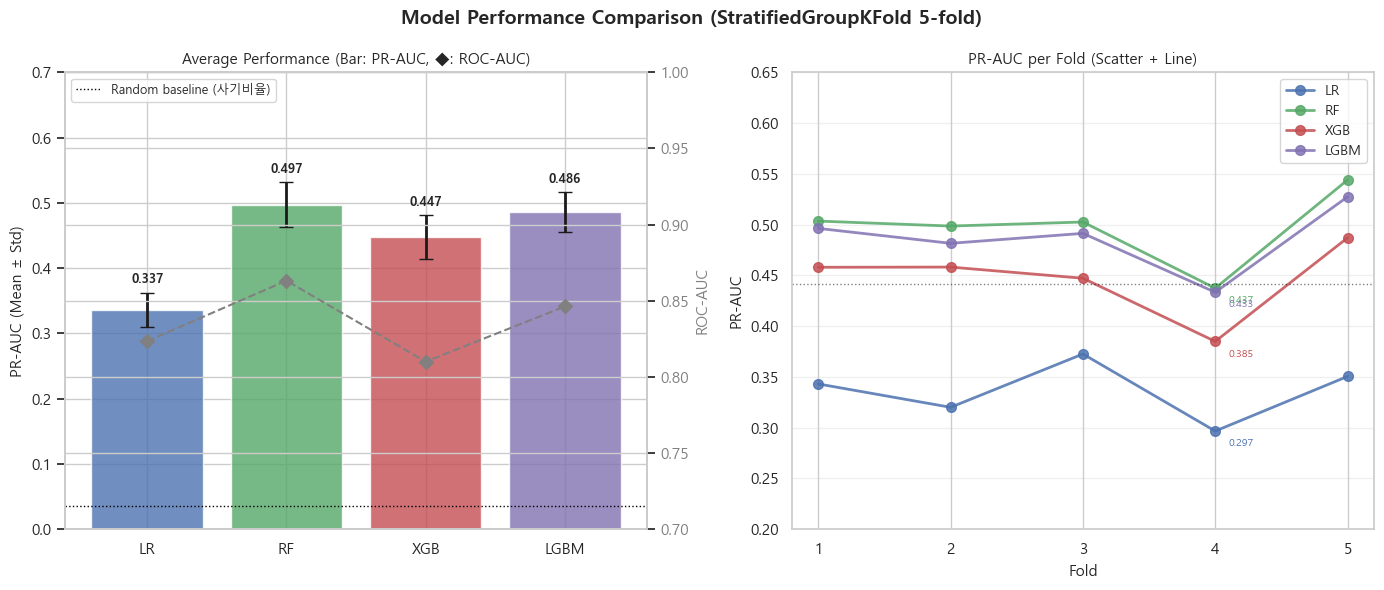

시각화 저장 완료: ../reports/figures/day4_model_comparison.png


In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# fold별 성능 데이터 정리
fold_data = {
    'Logistic Regression': [0.3431, 0.3201, 0.3726, 0.2967, 0.3505],
    'Random Forest':       [0.5035, 0.4986, 0.5026, 0.4374, 0.5440],
    'XGBoost':             [0.4580, 0.4582, 0.4472, 0.3850, 0.4870],
    'LightGBM':            [0.4963, 0.4816, 0.4914, 0.4334, 0.5274],
}

model_names = list(fold_data.keys())
pr_means = [results_df[results_df['model'] == m]['pr_auc_mean'].values[0] for m in model_names]
pr_stds  = [results_df[results_df['model'] == m]['pr_auc_std'].values[0] for m in model_names]
roc_means = [results_df[results_df['model'] == m]['roc_auc_mean'].values[0] for m in model_names]

colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
short_names = ['LR', 'RF', 'XGB', 'LGBM']
folds = [1, 2, 3, 4, 5]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Performance Comparison (StratifiedGroupKFold 5-fold)', fontsize=14, fontweight='bold')

# --- 왼쪽: Bar chart + 에러바 ---
ax1 = axes[0]
x = range(len(model_names))
bars = ax1.bar(x, pr_means, yerr=pr_stds, capsize=5,
               color=colors, alpha=0.8, error_kw={'linewidth': 2})

# ROC-AUC를 점으로 보조 표시
ax1_twin = ax1.twinx()
ax1_twin.plot(x, roc_means, 'D--', color='gray', markersize=7, linewidth=1.5, label='ROC-AUC')
ax1_twin.set_ylim(0.7, 1.0)
ax1_twin.set_ylabel('ROC-AUC', color='gray', fontsize=11)
ax1_twin.tick_params(axis='y', labelcolor='gray')

ax1.set_xticks(x)
ax1.set_xticklabels(short_names, fontsize=11)
ax1.set_ylabel('PR-AUC (Mean ± Std)', fontsize=11)
ax1.set_ylim(0, 0.7)
ax1.set_title('Average Performance (Bar: PR-AUC, ◆: ROC-AUC)', fontsize=11)
ax1.axhline(y=0.035, color='black', linestyle=':', linewidth=1, label='Random baseline (사기비율)')

for i, (mean, std) in enumerate(zip(pr_means, pr_stds)):
    ax1.text(i, mean + std + 0.01, f'{mean:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.legend(loc='upper left', fontsize=9)

# --- 오른쪽: Scatter + 연결선 (fold별 흐름) ---
ax2 = axes[1]
for i, (model, fold_scores) in enumerate(fold_data.items()):
    ax2.plot(folds, fold_scores, 'o-', color=colors[i], linewidth=2,
             markersize=7, label=short_names[i], alpha=0.85)
    # fold 4 저성능 강조 (모든 모델에서 낮은 fold)
    ax2.annotate(f'{fold_scores[3]:.3f}', xy=(4, fold_scores[3]),
                 xytext=(4.1, fold_scores[3] - 0.015),
                 fontsize=7.5, color=colors[i])

ax2.set_xticks(folds)
ax2.set_xlabel('Fold', fontsize=11)
ax2.set_ylabel('PR-AUC', fontsize=11)
ax2.set_ylim(0.2, 0.65)
ax2.set_title('PR-AUC per Fold (Scatter + Line)', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(y=np.mean(pr_means), color='black', linestyle=':', linewidth=1, alpha=0.5, label='전체 평균')

plt.tight_layout()
plt.savefig('../reports/figures/day4_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("시각화 저장 완료: ../reports/figures/day4_model_comparison.png")

### 시각화 해석 추가

**Fold 4에서 모든 모델이 동시에 하락**
- Fold 4에서 LR(0.297), XGB(0.385), RF(0.437), LGBM(0.433)이 전 모델에 걸쳐 일관되게 낮게 나타남
- 사기 비율은 StratifiedGroupKFold로 균등화(3.50%)되어 있으므로, 이는 클래스 비율 문제가 아니라 Fold 4의 validation에 할당된 UID 그룹의 구조적 특성에 기인하는 것으로 추정됨
- 예: 1건짜리 UID(사용자 패턴 파악 불가), 고빈도 UID(추정 식별자 신뢰도 낮음) 등이 Fold 4에 집중됐을 가능성이 있음
- 이는 모델의 한계가 아니라 "UID가 완벽한 개인 식별자가 아니다"라는 Day 3에서 명시한 데이터 구조적 한계와 일관된 결과로 해석됨

**XGBoost의 ROC-AUC가 Logistic Regression보다 낮은 역전 현상**
- PR-AUC 기준으로는 XGBoost(0.447)가 LR(0.337)을 크게 상회하나, ROC-AUC 기준으로는 XGBoost(0.810)가 LR(0.824)보다 낮게 나타나는 역전이 관찰됨
- PR-AUC는 소수 클래스(사기) 탐지 능력에 민감하고, ROC-AUC는 전반적인 클래스 구분력을 반영함
- 이 역전은 `scale_pos_weight=27.6` 설정이 사기 샘플을 과도하게 강조하여 소수 클래스 탐지에는 유리하지만, 전반적 구분력(ROC-AUC)은 오히려 저하된 결과로 해석됨
- 하이퍼파라미터 튜닝 단계에서 `scale_pos_weight` 조정 시 ROC-AUC 개선 여지가 있음

**지금부터의 흐름**

4.7절: 통계적 검증 (McNemar, DeLong, Bootstrap CI)
    → "어떤 모델 간 차이가 통계적으로 유의한가" 확인

    ↓

4.8절: Calibration 분석

    ↓

튜닝 (RF, LightGBM, XGBoost 3개)

    ↓
    
4.9절: Threshold Optimization (최종 선택 모델 기준)

### 10. Day 4 산출물 저장

Day 5(통계적 검증)에서 재학습 없이 바로 검증을 시작할 수 있도록, 각 모델의 out-of-fold 예측값(oof_preds)과 실제값(oof_labels)을 pickle로 저장합니다.

In [25]:
import pickle
import os

os.makedirs("../data/processed", exist_ok=True)

# oof_preds, oof_labels를 모델별로 딕셔너리로 저장
oof_results = {
    r['model']: {
        'oof_preds': r['oof_preds'],
        'oof_labels': r['oof_labels'],
        'pr_auc_mean': r['pr_auc_mean'],
        'pr_auc_std': r['pr_auc_std'],
        'roc_auc_mean': r['roc_auc_mean'],
        'roc_auc_std': r['roc_auc_std'],
    }
    for r in results
}

with open("../data/processed/day4_oof_results.pkl", 'wb') as f:
    pickle.dump(oof_results, f)

# 모델 비교 요약도 함께 저장
results_df.to_parquet("../data/processed/day4_results_summary.parquet", index=False)

print("저장 완료")
print(f"day4_oof_results.pkl: {os.path.getsize('../data/processed/day4_oof_results.pkl') / 1024**2:.2f} MB")
for model_name in oof_results:
    print(f"  {model_name}: oof_preds shape={oof_results[model_name]['oof_preds'].shape}")

저장 완료
day4_oof_results.pkl: 36.04 MB
  Logistic Regression: oof_preds shape=(590540,)
  Random Forest: oof_preds shape=(590540,)
  XGBoost: oof_preds shape=(590540,)
  LightGBM: oof_preds shape=(590540,)
